<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Vision Transformer (ViT): Como Transformers Enxergam Imagens

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

Neste notebook, vamos entender na pratica como o Vision Transformer (ViT) processa imagens. Vamos dividir uma imagem real em patches, visualizar o processo de embedding, usar um modelo pre-treinado para classificacao e extrair o mapa de atencao para ver onde o modelo esta "olhando".

## Importacoes

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import numpy as np

## Carregar uma imagem real

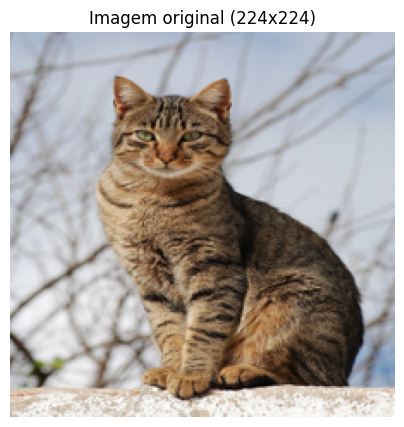

Tamanho da imagem: (224, 224)


In [2]:
# Carregar imagem de exemplo
url = "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/Vision-Transformer-ViT/cat-vit-example.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

# Redimensionar para 224x224 (tamanho esperado pelo ViT-B/16)
img = img.resize((224, 224))

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Imagem original (224x224)")
plt.axis("off")
plt.show()

print(f"Tamanho da imagem: {img.size}")

## Dividir a imagem em patches

O ViT divide a imagem em uma grade de quadrados (patches). Cada patch e tratado como um "token", assim como uma palavra em um modelo de linguagem.

In [3]:
# Parametros
patch_size = 16
img_size = 224
n_patches_lado = img_size // patch_size
n_patches_total = n_patches_lado ** 2

print(f"Imagem: {img_size}x{img_size}")
print(f"Patch: {patch_size}x{patch_size}")
print(f"Grade: {n_patches_lado}x{n_patches_lado} = {n_patches_total} patches")

Imagem: 224x224
Patch: 16x16
Grade: 14x14 = 196 patches


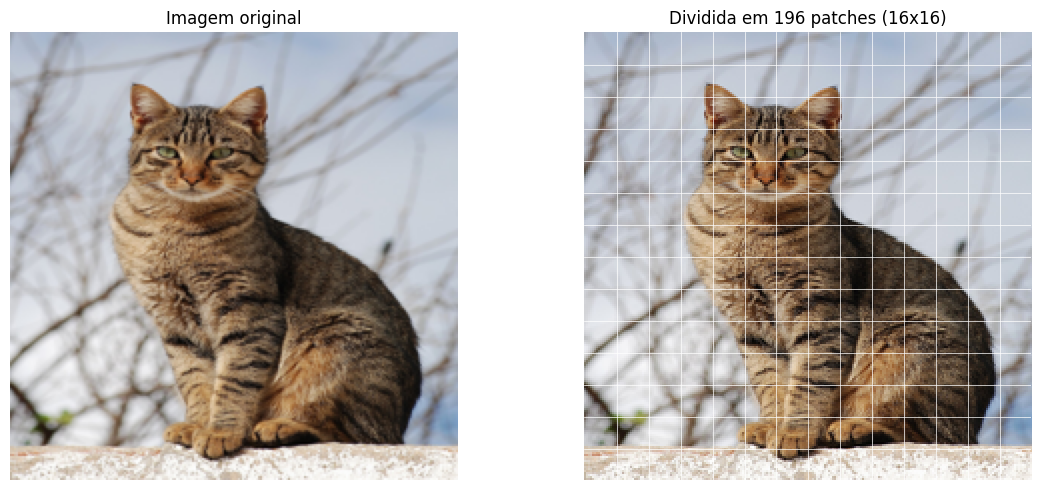

In [4]:
# Converter imagem para array numpy
img_array = np.array(img)

# Visualizar a grade de patches sobre a imagem
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagem original
axes[0].imshow(img_array)
axes[0].set_title("Imagem original")
axes[0].axis("off")

# Imagem com grade de patches
axes[1].imshow(img_array)
for i in range(1, n_patches_lado):
    axes[1].axhline(y=i * patch_size, color="white", linewidth=0.5)
    axes[1].axvline(x=i * patch_size, color="white", linewidth=0.5)
axes[1].set_title(f"Dividida em {n_patches_total} patches ({patch_size}x{patch_size})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

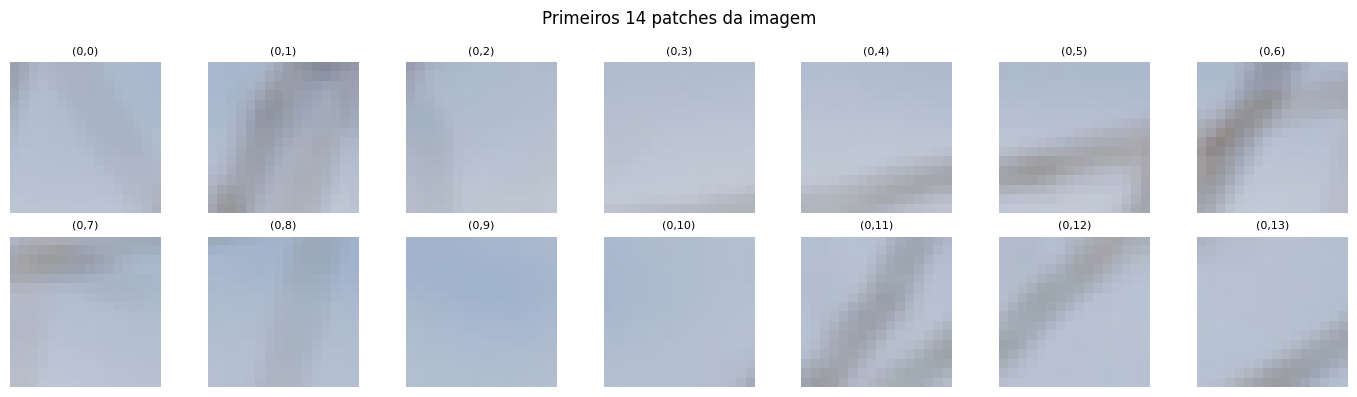

In [5]:
# Extrair e visualizar alguns patches individualmente
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for idx, ax in enumerate(axes.flat):
    i = idx // n_patches_lado
    j = idx % n_patches_lado
    patch = img_array[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
    ax.imshow(patch)
    ax.set_title(f"({i},{j})", fontsize=8)
    ax.axis("off")
plt.suptitle("Primeiros 14 patches da imagem")
plt.tight_layout()
plt.show()

## Patch Embedding com Conv2d

Na pratica, o ViT usa uma convolucao com kernel e stride iguais ao tamanho do patch. Essa operacao divide a imagem em patches e projeta cada um para um vetor de dimensao fixa em um unico passo.

In [6]:
# Converter imagem para tensor
img_tensor = torch.tensor(img_array, dtype=torch.float32).permute(2, 0, 1) / 255.0
img_batch = img_tensor.unsqueeze(0)  # adicionar dimensao do batch
print(f"Tensor da imagem: {img_batch.shape}")

# Patch embedding: Conv2d com kernel=16, stride=16
embed_dim = 768  # dimensao do ViT-Base
patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

with torch.no_grad():
    x = patch_embed(img_batch)
    print(f"Apos convolucao: {x.shape}")  # (1, 768, 14, 14)

    # Reorganizar para sequencia de tokens
    x = x.flatten(2).transpose(1, 2)
    print(f"Sequencia de tokens: {x.shape}")  # (1, 196, 768)
    print(f"Cada patch virou um vetor de {embed_dim} dimensoes")

Tensor da imagem: torch.Size([1, 3, 224, 224])
Apos convolucao: torch.Size([1, 768, 14, 14])
Sequencia de tokens: torch.Size([1, 196, 768])
Cada patch virou um vetor de 768 dimensoes


## Inferencia com ViT pre-treinado

Vamos usar o `vit_b_16` do torchvision, pre-treinado no ImageNet (1000 classes).

In [7]:
# Carregar modelo e pesos pre-treinados
weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)
model.eval()

# Pre-processar a imagem com as transformacoes do modelo
preprocess = weights.transforms()
img_input = preprocess(img).unsqueeze(0)
print(f"Entrada do modelo: {img_input.shape}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 153MB/s]


Entrada do modelo: torch.Size([1, 3, 224, 224])


In [8]:
# Realizar a inferencia
with torch.no_grad():
    output = model(img_input)
    probabilidades = F.softmax(output[0], dim=0)

# Top-5 predicoes
top5_prob, top5_idx = torch.topk(probabilidades, 5)
categorias = weights.meta["categories"]

print("Top-5 predicoes:")
print("-" * 40)
for i in range(5):
    print(f"  {categorias[top5_idx[i]]:30s} {top5_prob[i].item():.1%}")

Top-5 predicoes:
----------------------------------------
  tiger cat                      66.2%
  tabby                          16.1%
  Egyptian cat                   8.3%
  lynx                           0.2%
  tiger                          0.1%


## Visualizar o mapa de atencao

Vamos extrair os pesos de atencao de todas as camadas do Transformer e usar **attention rollout** para visualizar onde o CLS token esta prestando atencao na imagem. O rollout acumula a atencao camada a camada, levando em conta as conexoes residuais.

In [9]:
# Attention Rollout: acumular atencao de TODAS as camadas
with torch.no_grad():
    x = model._process_input(img_input)
    batch_cls = model.class_token.expand(x.shape[0], -1, -1)
    x = torch.cat([batch_cls, x], dim=1)
    x = x + model.encoder.pos_embedding
    x = model.encoder.dropout(x)

    # Coletar atencao de cada bloco
    all_attn = []
    for block in model.encoder.layers:
        x_norm = block.ln_1(x)
        attn_out, attn_weights = block.self_attention(
            x_norm, x_norm, x_norm, need_weights=True
        )
        all_attn.append(attn_weights)
        # Continuar o forward normal do bloco
        x = x + attn_out
        x = x + block.mlp(block.ln_2(x))

# Attention rollout: multiplicar as matrizes de atencao camada a camada
rollout = torch.eye(all_attn[0].shape[-1]).unsqueeze(0)
for attn in all_attn:
    # Somar identidade (conexao residual) e normalizar
    attn_with_residual = attn + torch.eye(attn.shape[-1]).unsqueeze(0)
    attn_with_residual = attn_with_residual / attn_with_residual.sum(dim=-1, keepdim=True)
    rollout = attn_with_residual @ rollout

# Extrair atencao acumulada do CLS para os patches
cls_attn = rollout[0, 0, 1:].reshape(n_patches_lado, n_patches_lado).numpy()
print(f"Mapa de atencao (rollout): {cls_attn.shape}")

Mapa de atencao (rollout): (14, 14)


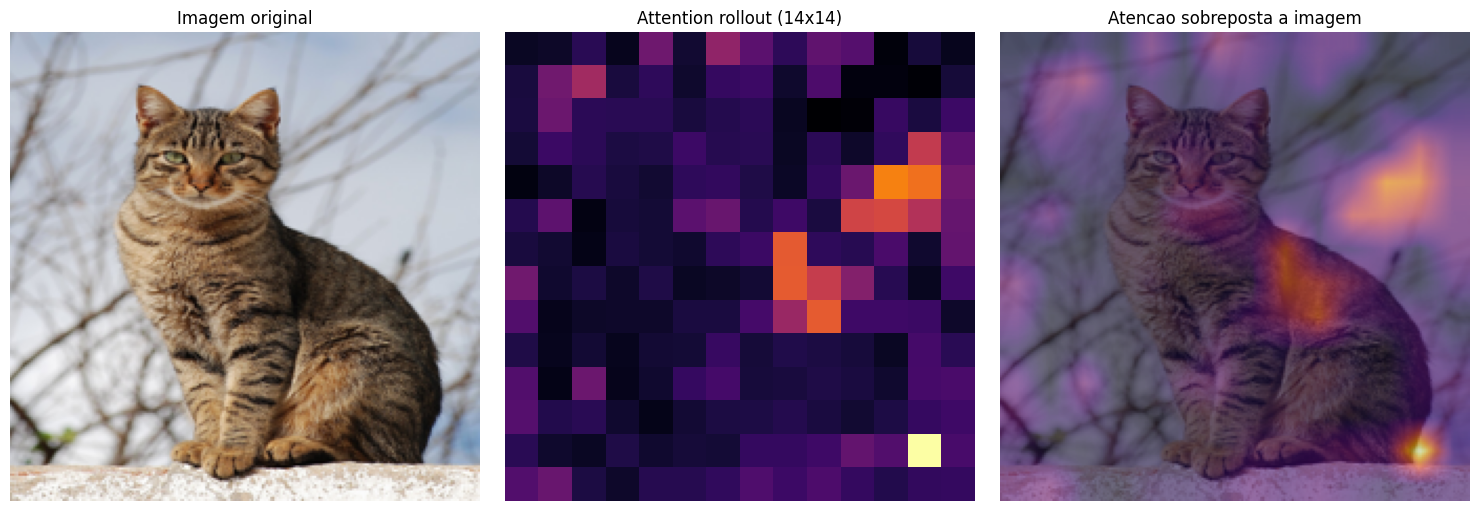

In [10]:
# Redimensionar o mapa de atencao para o tamanho da imagem
attn_resized = np.array(
    Image.fromarray((cls_attn / cls_attn.max() * 255).astype(np.uint8))
    .resize((img_size, img_size), Image.BILINEAR)
) / 255.0

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array)
axes[0].set_title("Imagem original")
axes[0].axis("off")

axes[1].imshow(cls_attn, cmap="inferno")
axes[1].set_title(f"Attention rollout ({n_patches_lado}x{n_patches_lado})")
axes[1].axis("off")

axes[2].imshow(img_array)
axes[2].imshow(attn_resized, cmap="inferno", alpha=0.6)
axes[2].set_title("Atencao sobreposta a imagem")
axes[2].axis("off")

plt.tight_layout()
plt.show()

As regioes mais claras no mapa de atencao indicam onde o modelo concentrou mais atencao para tomar sua decisao de classificacao. Em imagens de animais, o modelo tipicamente foca na cabeca e no corpo do animal, ignorando o fundo.